# Inspecting the precipitation nc files

In [1]:
import netCDF4 as nc
import os
import numpy as np

# ── SET YOUR FOLDER PATH HERE ──────────────────────────────────────────────
FOLDER_PATH = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION"   # <-- change this path, go to the root folder
# ──────────────────────────────────────────────────────────────────────────

nc_files = []
for root, dirs, files in os.walk(FOLDER_PATH):
    for f in files:
        if f.endswith((".nc", ".nc4", ".netcdf")):
            nc_files.append(os.path.join(root, f))

print(f"Found {len(nc_files)} NetCDF file(s)\n")
print("=" * 70)

for filepath in nc_files:
    print(f"\n📄 FILE : {filepath}")
    print("-" * 70)

    try:
        ds = nc.Dataset(filepath, "r")

        # ── Global attributes ─────────────────────────────────────────────
        print("\n[ GLOBAL ATTRIBUTES ]")
        for attr in ds.ncattrs():
            print(f"  {attr} : {getattr(ds, attr)}")

        # ── Dimensions ────────────────────────────────────────────────────
        print("\n[ DIMENSIONS ]")
        for dim_name, dim in ds.dimensions.items():
            print(f"  {dim_name} : size = {len(dim)}")

        # ── Variables ─────────────────────────────────────────────────────
        print("\n[ VARIABLES ]")
        for var_name, var in ds.variables.items():
            print(f"\n  >> {var_name}")
            print(f"     shape      : {var.shape}")
            print(f"     dtype      : {var.dtype}")
            print(f"     dimensions : {var.dimensions}")

            # Variable attributes
            for attr in var.ncattrs():
                print(f"     {attr} : {getattr(var, attr)}")

            # Sample values
            try:
                data = var[:]
                print(f"     min / max  : {np.nanmin(data):.4f} / {np.nanmax(data):.4f}")
                print(f"     sample     : {data.flatten()[:5]}")
            except Exception:
                print("     (could not read values)")

        ds.close()

    except Exception as e:
        print(f"  ⚠ Could not read file: {e}")

    print("=" * 70)

Found 5 NetCDF file(s)


📄 FILE : D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\anomaly_new.nc
----------------------------------------------------------------------

[ GLOBAL ATTRIBUTES ]
  CDI : Climate Data Interface version 2.4.0 (https://mpimet.mpg.de/cdi)
  Conventions : CF-1.7
  institution : European Centre for Medium-Range Weather Forecasts
  GRIB_centre : ecmf
  GRIB_centreDescription : European Centre for Medium-Range Weather Forecasts
  history : Thu Apr 16 13:53:33 2026: cdo ydaysub ERA5_merged_1980_2026_new.nc clim.nc anomaly_new.nc
Thu Apr 16 13:07:35 2026: cdo mergetime ERA5_Daily_Rainfall_1980.nc ERA5_Daily_Rainfall_1981.nc ERA5_Daily_Rainfall_1982.nc ERA5_Daily_Rainfall_1983.nc ERA5_Daily_Rainfall_1984.nc ERA5_Daily_Rainfall_1985.nc ERA5_Daily_Rainfall_1986.nc ERA5_Daily_Rainfall_1987.nc ERA5_Daily_Rainfall_1988.nc ERA5_Daily_Rainfall_1989.nc ERA5_Daily_Rainfall_1990.nc ERA5_Daily_Rainfall_1991.nc ERA5_Daily_Rainfall_1992.nc ERA5_Daily_Rainfall_1993.nc ERA5_Daily_Rainf

# Plotting the two cyclones with different precipitation files

## 1. Plotting total precipitation =>

Date range : 2025-10-22 → 2025-10-30  (9 days)
Precipitation  : Total Precip (mm/day)  ←  D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\ERA5_merged_1980_2026_new.nc
  Colorbar     : 0.0 → 5.0 mm/day  |  5 levels  |  cmap = YlGnBu
Loading Cyclone Montha track...
  → 32 points  |  2025-10-25 – 2025-10-29
Loading Arabian Sea Depression track...
  → 50 points  |  2025-10-22 – 2025-10-31
Loading India shapefile...
  ⚠ Shapefile skipped: Cannot transform naive geometries.  Please set a crs on the object first.
Grid       : 2 rows × 5 cols  |  Figure: 19.0 × 8.4 in

✅  Saved → cyclone_montha_october2025.png


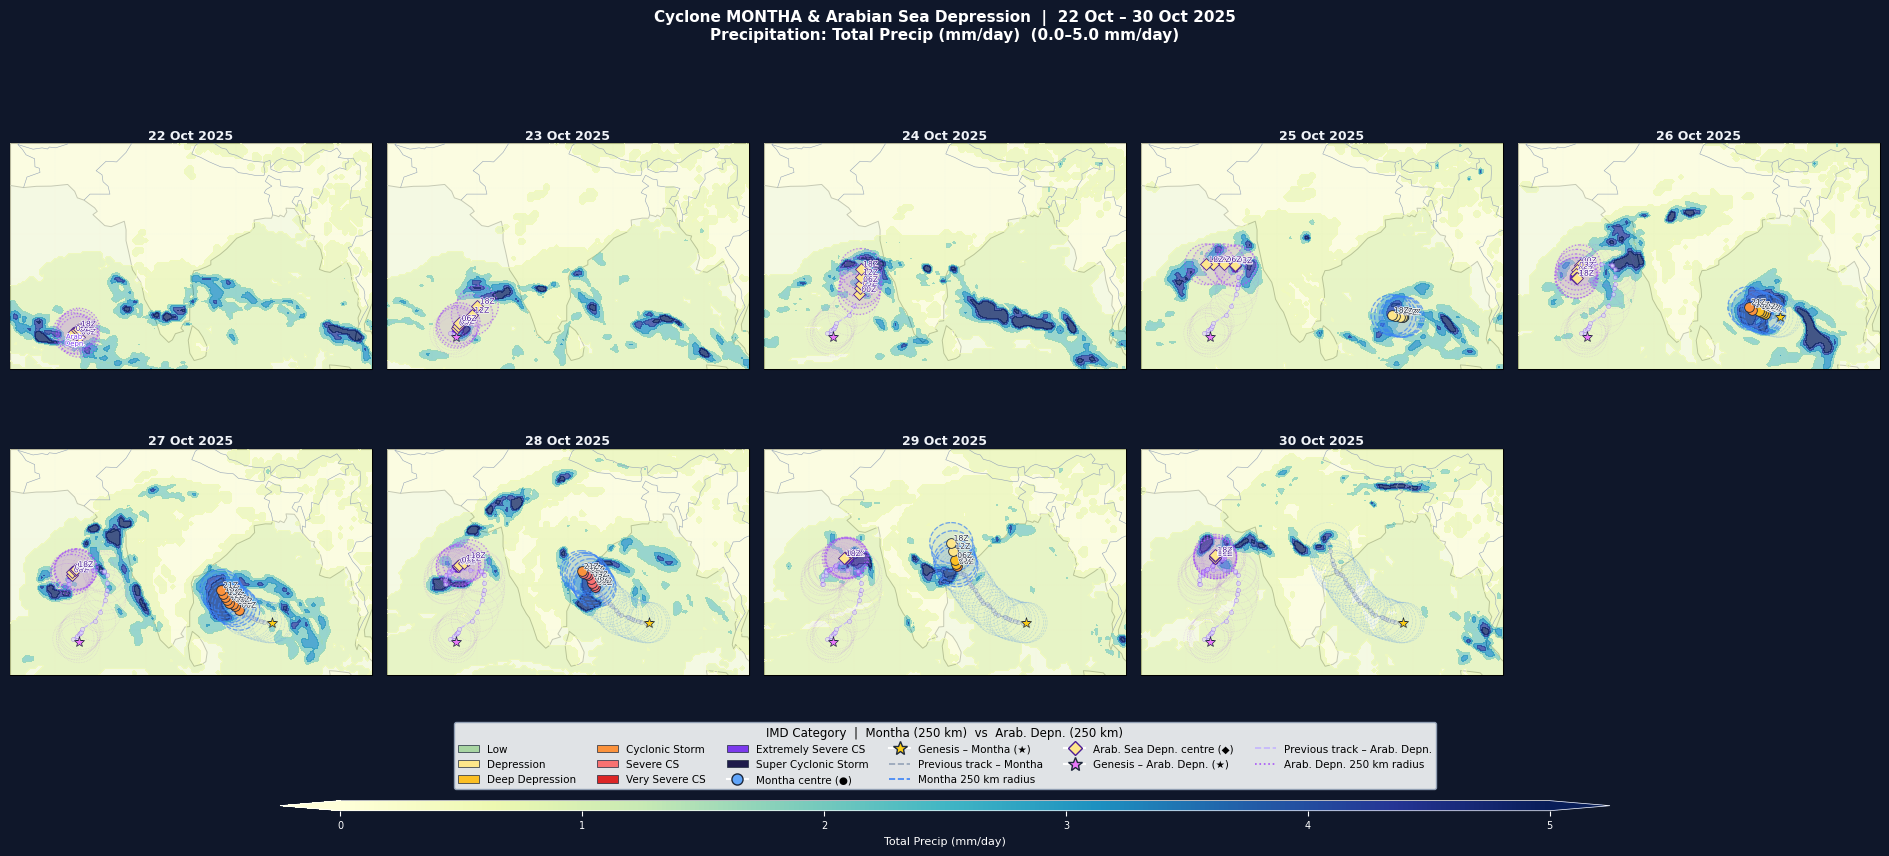

In [3]:
"""
=============================================================================
Cyclone MONTHA – Daily Track Maps  |  Precipitation Overlay + Dual Cyclone
=============================================================================
REQUIREMENTS:
    pip install matplotlib cartopy geopandas pandas openpyxl numpy netCDF4
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import netCDF4 as nc
from datetime import datetime, timedelta
from datetime import date as date_type
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# ── USER CONFIGURATION  (edit only this section) ─────────────────────────────
# =============================================================================

EXCEL_FILE     = r"D:\PHD 2025~\LOW PRESSURE TRACKS\SCS_Montha_Oct_2025.xlsx"
EXCEL_FILE_2   = r"D:\PHD 2025~\LOW PRESSURE TRACKS\D_Arabian_Sea_Oct_2025.xlsx"
SHAPEFILE_PATH = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# ── PRECIPITATION NetCDF FILES ────────────────────────────────────────────────
PRECIP_TOTAL_FILE   = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\ERA5_merged_1980_2026_new.nc"
PRECIP_ANOMALY_FILE = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\anomaly_new.nc"
PRECIP_NONMJO_FILE  = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\non_mjo.nc"
PRECIP_MJO_FILE     = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\lanczos_mjo_only.nc"

# =============================================================================
# ── PRECIPITATION SWITCHES ────────────────────────────────────────────────────
#
#  Turn ON exactly ONE switch at a time.
#  True  = that file's data will be plotted as the background shading.
#  False = skip.
#
#  Only the FIRST True switch in this list will be used if you
#  accidentally set more than one to True — a warning will be printed.
# =============================================================================

USE_TOTAL_PRECIP   = True   # ERA5 merged  |  variable: tp     |  only ≥ 0  mm/day
USE_PRECIP_ANOMALY = False   # anomaly_new  |  variable: tp     |  can be +/−
USE_NONMJO_PRECIP  = False   # non_mjo      |  variable: tp_non_mjo  |  can be +/−
USE_MJO_PRECIP     = False   # lanczos_mjo  |  variable: tp_mjo |  can be +/−

# =============================================================================
# ── COLORBAR LIMITS & DIVISIONS ───────────────────────────────────────────────
#
#  Set the min / max of the colorbar and how many contour levels to use.
#
#  For TOTAL PRECIP (only positive):
#    PRECIP_VMIN =  0.0,  PRECIP_VMAX = 25.0,  PRECIP_LEVELS = 13
#
#  For ANOMALY / MJO / NON-MJO (positive and negative):
#    PRECIP_VMIN = -15.0, PRECIP_VMAX = 15.0,  PRECIP_LEVELS = 13
#
#  PRECIP_LEVELS = number of colour bands  (more = finer gradation)
#    e.g. 11 → steps of ~2.5 mm  |  21 → steps of ~1.25 mm
# =============================================================================

PRECIP_VMIN   =  0.0    # lower limit  (mm/day)
PRECIP_VMAX   = 5.0    # upper limit  (mm/day)
PRECIP_LEVELS = 5      # number of colour bands

PRECIP_ALPHA  = 0.72    # transparency of precipitation shading (0=invisible, 1=solid)

# =============================================================================
# ── COLORMAP SELECTION ────────────────────────────────────────────────────────
#
#  The code auto-selects a sensible colormap based on which switch is ON,
#  but you can override here:
#
#  For total (only positive)  → "YlGnBu"  (yellow → green → blue)
#  For anomaly / MJO / non-MJO (diverging) →
#       "RdYlGn"  red (−) → yellow (0) → green (+)   ← default
#       "BrBG"    brown (−) → white (0) → teal (+)
#       "RdBu_r"  red (−) → white (0) → blue (+)
#
#  Set to None to let the code auto-pick based on active switch.
# =============================================================================

COLORMAP_OVERRIDE = None    # e.g.  "RdYlGn"  or  None


# ── DATE RANGE ───────────────────────────────────────────────────────────────
START_DATE = "22-10-2025"
END_DATE   = "30-10-2025"

# ── LAYOUT ───────────────────────────────────────────────────────────────────
NCOLS = 5

# ── SUBPLOT SIZE ─────────────────────────────────────────────────────────────
PLOT_WIDTH_PER_COL  = 3.8
PLOT_HEIGHT_PER_ROW = 4.2

# ── MAP DOMAIN  [lon_min, lon_max, lat_min, lat_max] ─────────────────────────
MAP_EXTENT = [60, 100, 5, 30]

# ── CUMULATIVE TRACK STYLE (Montha – primary) ─────────────────────────────────
CUMUL_LINE_COLOR  = "#94a3b8"
CUMUL_LINE_WIDTH  = 1.0
CUMUL_LINE_STYLE  = "--"
CUMUL_DOT_COLOR   = "#cbd5e1"
CUMUL_DOT_SIZE    = 3
CUMUL_DOT_ALPHA   = 0.6

# ── CUMULATIVE TRACK STYLE (Arabian Sea Depression – secondary) ───────────────
CUMUL2_LINE_COLOR = "#c4b5fd"
CUMUL2_LINE_WIDTH = 1.0
CUMUL2_LINE_STYLE = "--"
CUMUL2_DOT_COLOR  = "#ddd6fe"
CUMUL2_DOT_SIZE   = 3
CUMUL2_DOT_ALPHA  = 0.6

# ── RADIUS CIRCLE CONFIGURATION ───────────────────────────────────────────────
MONTHA_RADIUS_KM         = 250
MONTHA_CIRCLE_COLOR      = "#3b82f6"
MONTHA_CIRCLE_LINEWIDTH  = 0.9
MONTHA_CIRCLE_LINESTYLE  = "--"
MONTHA_CIRCLE_ALPHA      = 0.70
MONTHA_CIRCLE_FILL_COLOR = "#3b82f6"
MONTHA_CIRCLE_FILL_ALPHA = 0.06
MONTHA_DRAW_CIRCLE       = True

ARAB_RADIUS_KM           = 250
ARAB_CIRCLE_COLOR        = "#a855f7"
ARAB_CIRCLE_LINEWIDTH    = 0.9
ARAB_CIRCLE_LINESTYLE    = ":"
ARAB_CIRCLE_ALPHA        = 0.70
ARAB_CIRCLE_FILL_COLOR   = "#a855f7"
ARAB_CIRCLE_FILL_ALPHA   = 0.06
ARAB_DRAW_CIRCLE         = True

# ── OUTPUT ───────────────────────────────────────────────────────────────────
OUTPUT_FILE          = "cyclone_montha_october2025.png"
OUTPUT_DPI           = 180
SAVE_INDIVIDUAL_DAYS = False


# =============================================================================
# ── CATEGORY COLOUR MAP (IMD scale) ──────────────────────────────────────────
# =============================================================================

CATEGORY_COLORS = {
    "L"   : "#a8d5a2",
    "D"   : "#fde68a",
    "DD"  : "#fbbf24",
    "CS"  : "#fb923c",
    "SCS" : "#f87171",
    "VSCS": "#dc2626",
    "ESCS": "#7c3aed",
    "SuCS": "#1e1b4b",
}
DEFAULT_COLOR = "#60a5fa"

CATEGORY_LABELS = {
    "L"   : "Low",
    "D"   : "Depression",
    "DD"  : "Deep Depression",
    "CS"  : "Cyclonic Storm",
    "SCS" : "Severe CS",
    "VSCS": "Very Severe CS",
    "ESCS": "Extremely Severe CS",
    "SuCS": "Super Cyclonic Storm",
}

def cat_color(cat):
    return CATEGORY_COLORS.get(str(cat).strip(), DEFAULT_COLOR)

def cat_label(cat):
    return CATEGORY_LABELS.get(str(cat).strip(), str(cat).strip())


# =============================================================================
# ── PRECIPITATION LOADER ──────────────────────────────────────────────────────
# =============================================================================

def resolve_precip_config():
    """
    Read the four switches and return:
        (filepath, varname, is_diverging, label)
    Only the first True switch wins. Returns None if all are False.
    """
    candidates = [
        (USE_TOTAL_PRECIP,   PRECIP_TOTAL_FILE,   "tp",         False, "Total Precip (mm/day)"),
        (USE_PRECIP_ANOMALY, PRECIP_ANOMALY_FILE,  "tp",         True,  "Precip Anomaly (mm/day)"),
        (USE_NONMJO_PRECIP,  PRECIP_NONMJO_FILE,   "tp_non_mjo", True,  "Non-MJO Precip (mm/day)"),
        (USE_MJO_PRECIP,     PRECIP_MJO_FILE,      "tp_mjo",     True,  "MJO Precip (mm/day)"),
    ]
    active = [(fp, vn, div, lbl) for flag, fp, vn, div, lbl in candidates if flag]
    if len(active) == 0:
        return None
    if len(active) > 1:
        print(f"  ⚠ WARNING: {len(active)} precipitation switches are ON. "
              f"Using only the first one: '{active[0][3]}'")
    return active[0]   # (filepath, varname, is_diverging, label)


def load_precip_dataset(filepath, varname):
    """
    Open a NetCDF file and return (ds, lons, lats, time_array).
    Keeps the dataset open — caller must close ds when done.
    time_array is an array of Python date objects.
    """
    ds        = nc.Dataset(filepath, "r")
    lons      = ds.variables["longitude"][:]
    lats      = ds.variables["latitude"][:]

    # time dimension name differs between files
    t_key     = "valid_time" if "valid_time" in ds.variables else "time"
    t_raw     = ds.variables[t_key][:]            # seconds since 1970-01-01
    times     = np.array([
        (datetime(1970, 1, 1) + timedelta(seconds=float(s))).date()
        for s in t_raw
    ])
    return ds, lons, lats, times, t_key


def get_precip_field(ds, varname, times, target_date):
    """
    Extract the 2-D precipitation field (lat × lon) for target_date.
    Converts m/day → mm/day.
    Returns None if the date is not found.
    """
    idx_arr = np.where(times == target_date)[0]
    if len(idx_arr) == 0:
        return None
    idx  = idx_arr[0]
    data = ds.variables[varname][idx, :, :]   # shape: (lat, lon)
    data = np.ma.filled(data, np.nan)
    data = data * 1000.0                       # m → mm
    return data


def build_colormap(is_diverging):
    """
    Return a colormap appropriate for the data type.
    Respects COLORMAP_OVERRIDE if set.
    """
    if COLORMAP_OVERRIDE is not None:
        return plt.get_cmap(COLORMAP_OVERRIDE)
    if is_diverging:
        # Red(−) → Yellow(0) → Green(+)  – intuitive for rainfall anomalies
        return plt.get_cmap("RdYlGn")
    else:
        # Yellow → Green → Blue  – classic positive-only rainfall
        return plt.get_cmap("YlGnBu")


# =============================================================================
# ── GEODESIC RADIUS CIRCLE ────────────────────────────────────────────────────
# =============================================================================

def draw_radius_circle(ax, centre_lon, centre_lat, radius_km, proj,
                       color="#3b82f6", linewidth=0.9, linestyle="--",
                       alpha=0.7, fill_color="none", fill_alpha=0.07,
                       n_pts=180):
    R_EARTH  = 6371.0
    d        = radius_km / R_EARTH
    lat_r    = np.radians(centre_lat)
    bearings = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)

    ring_lats = np.degrees(
        np.arcsin(np.sin(lat_r) * np.cos(d) +
                  np.cos(lat_r) * np.sin(d) * np.cos(bearings))
    )
    ring_lons = centre_lon + np.degrees(
        np.arctan2(np.sin(bearings) * np.sin(d) * np.cos(lat_r),
                   np.cos(d) - np.sin(lat_r) * np.sin(np.radians(ring_lats)))
    )
    ring_lons = np.append(ring_lons, ring_lons[0])
    ring_lats = np.append(ring_lats, ring_lats[0])

    if fill_color != "none":
        ax.fill(ring_lons, ring_lats, color=fill_color,
                alpha=fill_alpha, transform=proj, zorder=7)
    ax.plot(ring_lons, ring_lats, linestyle=linestyle, color=color,
            linewidth=linewidth, alpha=alpha, transform=proj, zorder=8)


# =============================================================================
# ── OVERLAY MODULE REGISTRY ───────────────────────────────────────────────────
# =============================================================================

OVERLAY_MODULES = []


# =============================================================================
# ── SECOND SYSTEM OVERLAY  (Arabian Sea Depression) ──────────────────────────
# =============================================================================

def overlay_second_system(ax, day_date, proj, second_track_df=None, **kwargs):
    if second_track_df is None or second_track_df.empty:
        return

    past = second_track_df[second_track_df["date"] < day_date]
    if not past.empty:
        p_lons, p_lats = past["lon"].values, past["lat"].values
        ax.plot(p_lons, p_lats, CUMUL2_LINE_STYLE, color=CUMUL2_LINE_COLOR,
                linewidth=CUMUL2_LINE_WIDTH, transform=proj, zorder=6, alpha=0.8)
        ax.plot(p_lons, p_lats, "o", color=CUMUL2_DOT_COLOR,
                markersize=CUMUL2_DOT_SIZE, markeredgecolor="#7c3aed",
                markeredgewidth=0.3, transform=proj, zorder=6,
                alpha=CUMUL2_DOT_ALPHA)
        if ARAB_DRAW_CIRCLE:
            for plon, plat in zip(p_lons, p_lats):
                draw_radius_circle(ax, plon, plat, ARAB_RADIUS_KM, proj,
                    color=ARAB_CIRCLE_COLOR,
                    linewidth=max(0.3, ARAB_CIRCLE_LINEWIDTH * 0.5),
                    linestyle=ARAB_CIRCLE_LINESTYLE,
                    alpha=ARAB_CIRCLE_ALPHA * 0.35, fill_color="none")
        ax.plot(p_lons[0], p_lats[0], "*", color="#e879f9", markersize=8,
                markeredgecolor="#1e293b", markeredgewidth=0.5,
                transform=proj, zorder=9)

    day_data = second_track_df[second_track_df["date"] == day_date]
    if day_data.empty:
        return

    lons, lats   = day_data["lon"].values, day_data["lat"].values
    cats, hours  = day_data["category"].values, day_data["hour"].values

    if ARAB_DRAW_CIRCLE:
        for lon, lat in zip(lons, lats):
            draw_radius_circle(ax, lon, lat, ARAB_RADIUS_KM, proj,
                color=ARAB_CIRCLE_COLOR, linewidth=ARAB_CIRCLE_LINEWIDTH,
                linestyle=ARAB_CIRCLE_LINESTYLE, alpha=ARAB_CIRCLE_ALPHA,
                fill_color=ARAB_CIRCLE_FILL_COLOR,
                fill_alpha=ARAB_CIRCLE_FILL_ALPHA)

    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#6d28d9", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)
        for i in range(len(lons) - 1):
            dx = lons[i+1]-lons[i]; dy = lats[i+1]-lats[i]
            mx = (lons[i]+lons[i+1])/2; my = (lats[i]+lats[i+1])/2
            ax.annotate("", xy=(mx+dx*0.01, my+dy*0.01),
                xytext=(mx-dx*0.01, my-dy*0.01),
                xycoords=proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#6d28d9",
                                lw=1.0, mutation_scale=8), zorder=8)

    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "D", color=cat_color(cat), markersize=6,
                markeredgecolor="#4c1d95", markeredgewidth=0.6,
                transform=proj, zorder=10)
        ax.text(lon+0.25, lat+0.25, f"{int(hr):02d}Z", fontsize=5.5,
                color="#4c1d95", transform=proj, zorder=11,
                path_effects=[pe.withStroke(linewidth=1.0, foreground="white")])

    first_date = second_track_df["date"].min()
    if day_date == first_date and len(lons) > 0:
        ax.text(lons[0]-0.4, lats[0]-1.0, "Arab.\nDepn.", fontsize=5,
                color="#7c3aed", ha="center", transform=proj, zorder=12,
                path_effects=[pe.withStroke(linewidth=1.2, foreground="white")])


OVERLAY_MODULES.append(overlay_second_system)


# =============================================================================
# ── LOAD & CLEAN EXCEL ────────────────────────────────────────────────────────
# =============================================================================

def load_track(excel_path):
    df = pd.read_excel(excel_path, sheet_name="Sheet1")
    df = df[["Date", "Time (UTC)", "Lat (°N)", "Long (°E)",
             "ECP (hPa)", "ΔP (hPa)", "C.I. No.", "MSW (kt)", "Category"]].copy()
    df.columns = ["date_str","time_utc","lat","lon","ecp","delta_p","ci","msw","category"]
    df = df.dropna(subset=["lat","lon","date_str"])
    df["date"]     = pd.to_datetime(df["date_str"], format="%d.%m.%Y").dt.date
    df["time_utc"] = pd.to_numeric(df["time_utc"], errors="coerce").fillna(0).astype(int)
    df["hour"]     = df["time_utc"] // 100
    df = df.sort_values(["date","time_utc"]).reset_index(drop=True)
    return df


# =============================================================================
# ── DRAW ONE DAY'S SUBPLOT ────────────────────────────────────────────────────
# =============================================================================

def draw_day(ax, day_date, track_df, past_track_df, india_shp, proj,
             overlay_kwargs=None,
             precip_ds=None, precip_lons=None, precip_lats=None,
             precip_times=None, precip_varname=None,
             precip_cmap=None, precip_norm=None):

    ax.set_extent(MAP_EXTENT, crs=proj)

    # ── Base map ──────────────────────────────────────────────────────────────
    ax.add_feature(cfeature.OCEAN.with_scale("110m"),
                   facecolor="#dbeafe", zorder=1)
    ax.add_feature(cfeature.LAND.with_scale("110m"),
                   facecolor="#f1f5f9", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"),
                   linewidth=0.7, edgecolor="#334155", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),
                   linewidth=0.4, edgecolor="#94a3b8", zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.3,
                 color="#cbd5e1", alpha=0.5, linestyle="--", zorder=2)

    if india_shp is not None:
        india_shp.boundary.plot(ax=ax, linewidth=0.8, edgecolor="#1e293b",
                                facecolor="none", transform=proj, zorder=5)

    ax.set_title(day_date.strftime("%d %b %Y"), fontsize=9,
                 fontweight="bold", color="#f0f3f8", pad=3)

    # ── Precipitation shading ─────────────────────────────────────────────────
    if precip_ds is not None:
        field = get_precip_field(precip_ds, precip_varname,
                                 precip_times, day_date)
        if field is not None:
            # For total precip: mask negative values (artifacts)
            if not precip_norm.vmin < 0:
                field = np.where(field < 0, np.nan, field)

            cf = ax.contourf(
                precip_lons, precip_lats, field,
                levels=np.linspace(PRECIP_VMIN, PRECIP_VMAX, PRECIP_LEVELS),
                cmap=precip_cmap, norm=precip_norm,
                transform=proj, alpha=PRECIP_ALPHA,
                zorder=3, extend="both"
            )

    # ── Overlay modules ───────────────────────────────────────────────────────
    if overlay_kwargs is None:
        overlay_kwargs = {}
    for module_fn in OVERLAY_MODULES:
        module_fn(ax, day_date, proj, **overlay_kwargs)

    # ── CUMULATIVE TRACK – Montha ─────────────────────────────────────────────
    if past_track_df is not None and not past_track_df.empty:
        p_lons, p_lats = past_track_df["lon"].values, past_track_df["lat"].values
        ax.plot(p_lons, p_lats, CUMUL_LINE_STYLE, color=CUMUL_LINE_COLOR,
                linewidth=CUMUL_LINE_WIDTH, transform=proj, zorder=6, alpha=0.8)
        ax.plot(p_lons, p_lats, "o", color=CUMUL_DOT_COLOR,
                markersize=CUMUL_DOT_SIZE, markeredgecolor="#64748b",
                markeredgewidth=0.3, transform=proj, zorder=6, alpha=CUMUL_DOT_ALPHA)
        if MONTHA_DRAW_CIRCLE:
            for plon, plat in zip(p_lons, p_lats):
                draw_radius_circle(ax, plon, plat, MONTHA_RADIUS_KM, proj,
                    color=MONTHA_CIRCLE_COLOR,
                    linewidth=max(0.3, MONTHA_CIRCLE_LINEWIDTH * 0.5),
                    linestyle=MONTHA_CIRCLE_LINESTYLE,
                    alpha=MONTHA_CIRCLE_ALPHA * 0.35, fill_color="none")
        ax.plot(p_lons[0], p_lats[0], "*", color="#facc15", markersize=8,
                markeredgecolor="#1e293b", markeredgewidth=0.5,
                transform=proj, zorder=9)

    # ── TODAY'S TRACK – Montha ────────────────────────────────────────────────
    day_data = track_df[track_df["date"] == day_date]
    if day_data.empty:
        return

    lons, lats   = day_data["lon"].values, day_data["lat"].values
    cats, hours  = day_data["category"].values, day_data["hour"].values

    if MONTHA_DRAW_CIRCLE:
        for lon, lat in zip(lons, lats):
            draw_radius_circle(ax, lon, lat, MONTHA_RADIUS_KM, proj,
                color=MONTHA_CIRCLE_COLOR, linewidth=MONTHA_CIRCLE_LINEWIDTH,
                linestyle=MONTHA_CIRCLE_LINESTYLE, alpha=MONTHA_CIRCLE_ALPHA,
                fill_color=MONTHA_CIRCLE_FILL_COLOR,
                fill_alpha=MONTHA_CIRCLE_FILL_ALPHA)

    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#1e3a5f", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)
        for i in range(len(lons) - 1):
            dx = lons[i+1]-lons[i]; dy = lats[i+1]-lats[i]
            mx = (lons[i]+lons[i+1])/2; my = (lats[i]+lats[i+1])/2
            ax.annotate("", xy=(mx+dx*0.01, my+dy*0.01),
                xytext=(mx-dx*0.01, my-dy*0.01),
                xycoords=proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#1e3a5f",
                                lw=1.0, mutation_scale=8), zorder=8)

    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "o", color=cat_color(cat), markersize=7,
                markeredgecolor="#1e293b", markeredgewidth=0.6,
                transform=proj, zorder=10)
        ax.text(lon+0.25, lat+0.25, f"{int(hr):02d}Z", fontsize=5.5,
                color="#1e293b", transform=proj, zorder=11,
                path_effects=[pe.withStroke(linewidth=1.0, foreground="white")])


# =============================================================================
# ── MAIN ─────────────────────────────────────────────────────────────────────
# =============================================================================

def main():

    proj = ccrs.PlateCarree()

    # ── Date range ────────────────────────────────────────────────────────────
    start     = datetime.strptime(START_DATE, "%d-%m-%Y").date()
    end       = datetime.strptime(END_DATE,   "%d-%m-%Y").date()
    date_list = [start + timedelta(days=i)
                 for i in range((end - start).days + 1)]
    n_days = len(date_list)
    print(f"Date range : {start} → {end}  ({n_days} days)")

    # ── Resolve which precipitation file to use ───────────────────────────────
    precip_cfg = resolve_precip_config()
    precip_ds = precip_lons = precip_lats = precip_times = None
    precip_varname = precip_cmap = precip_norm = None
    precip_label = ""

    if precip_cfg is not None:
        fp, varname, is_diverging, precip_label = precip_cfg
        print(f"Precipitation  : {precip_label}  ←  {fp}")
        precip_ds, precip_lons, precip_lats, precip_times, _ = \
            load_precip_dataset(fp, varname)
        precip_varname = varname
        precip_cmap    = build_colormap(is_diverging)
        precip_norm    = mcolors.Normalize(vmin=PRECIP_VMIN, vmax=PRECIP_VMAX)
        print(f"  Colorbar     : {PRECIP_VMIN} → {PRECIP_VMAX} mm/day  "
              f"|  {PRECIP_LEVELS} levels  |  cmap = {precip_cmap.name}")
    else:
        print("Precipitation  : OFF (all switches are False)")

    # ── Track data ────────────────────────────────────────────────────────────
    print("Loading Cyclone Montha track...")
    track_df = load_track(EXCEL_FILE)
    print(f"  → {len(track_df)} points  |  "
          f"{track_df['date'].min()} – {track_df['date'].max()}")

    print("Loading Arabian Sea Depression track...")
    try:
        track_df2 = load_track(EXCEL_FILE_2)
        print(f"  → {len(track_df2)} points  |  "
              f"{track_df2['date'].min()} – {track_df2['date'].max()}")
    except Exception as e:
        print(f"  ⚠ Second system skipped: {e}")
        track_df2 = None

    # ── Shapefile ─────────────────────────────────────────────────────────────
    print("Loading India shapefile...")
    try:
        india_shp = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
        print(f"  → {len(india_shp)} features")
    except Exception as e:
        print(f"  ⚠ Shapefile skipped: {e}")
        india_shp = None

    # ── Figure grid ───────────────────────────────────────────────────────────
    ncols = NCOLS
    nrows = int(np.ceil(n_days / ncols))
    fig_w = ncols * PLOT_WIDTH_PER_COL
    fig_h = nrows * PLOT_HEIGHT_PER_ROW
    print(f"Grid       : {nrows} rows × {ncols} cols  |  "
          f"Figure: {fig_w:.1f} × {fig_h:.1f} in")

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="#0f172a")

    # Build title — include which precipitation layer is active
    precip_title = precip_label if precip_label else "No precipitation overlay"
    fig.suptitle(
        f"Cyclone MONTHA & Arabian Sea Depression  |  "
        f"{start.strftime('%d %b')} – {end.strftime('%d %b %Y')}\n"
        f"Precipitation: {precip_title}  "
        f"({PRECIP_VMIN}–{PRECIP_VMAX} mm/day)",
        fontsize=11, fontweight="bold", color="white",
        y=0.999, va="top"
    )

    overlay_kwargs = {"second_track_df": track_df2}

    # ── Draw subplots ─────────────────────────────────────────────────────────
    for idx, day_date in enumerate(date_list):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)

        past_mask  = track_df["date"] < day_date
        past_track = track_df[past_mask].copy() if past_mask.any() else None

        draw_day(
            ax, day_date, track_df, past_track, india_shp, proj,
            overlay_kwargs   = overlay_kwargs,
            precip_ds        = precip_ds,
            precip_lons      = precip_lons,
            precip_lats      = precip_lats,
            precip_times     = precip_times,
            precip_varname   = precip_varname,
            precip_cmap      = precip_cmap,
            precip_norm      = precip_norm,
        )

        if SAVE_INDIVIDUAL_DAYS:
            sf = plt.figure(figsize=(PLOT_WIDTH_PER_COL*1.5,
                                     PLOT_HEIGHT_PER_ROW*1.5))
            sa = sf.add_subplot(1, 1, 1, projection=proj)
            draw_day(sa, day_date, track_df, past_track, india_shp, proj,
                     overlay_kwargs=overlay_kwargs,
                     precip_ds=precip_ds, precip_lons=precip_lons,
                     precip_lats=precip_lats, precip_times=precip_times,
                     precip_varname=precip_varname,
                     precip_cmap=precip_cmap, precip_norm=precip_norm)
            sf.savefig(f"day_{day_date}.png", dpi=OUTPUT_DPI,
                       bbox_inches="tight")
            plt.close(sf)

    # Hide unused panels
    for idx in range(n_days, nrows * ncols):
        fig.add_subplot(nrows, ncols, idx + 1).set_visible(False)

    # ── Shared precipitation colorbar ────────────────────────────────────────
    if precip_ds is not None:
        sm = plt.cm.ScalarMappable(cmap=precip_cmap, norm=precip_norm)
        sm.set_array([])
        cbar_ax = fig.add_axes([0.15, 0.045, 0.70, 0.012])  # [left,bottom,w,h]
        cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                          extend="both")
        cb.set_label(precip_label, color="white", fontsize=8)
        cb.ax.xaxis.set_tick_params(color="white", labelsize=7)
        plt.setp(cb.ax.xaxis.get_ticklabels(), color="white")
        cb.outline.set_edgecolor("white")
        cb.outline.set_linewidth(0.5)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=color, edgecolor="#1e293b",
                       linewidth=0.5, label=cat_label(cat))
        for cat, color in CATEGORY_COLORS.items()
    ]
    legend_handles += [
        plt.Line2D([0],[0], marker="o", color="w",
                   markerfacecolor="#60a5fa", markeredgecolor="#1e293b",
                   markersize=8, label="Montha centre (●)"),
        plt.Line2D([0],[0], marker="*", color="w",
                   markerfacecolor="#facc15", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Montha (★)"),
        plt.Line2D([0],[0], linestyle=CUMUL_LINE_STYLE,
                   color=CUMUL_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Montha"),
        plt.Line2D([0],[0], linestyle=MONTHA_CIRCLE_LINESTYLE,
                   color=MONTHA_CIRCLE_COLOR, linewidth=1.2,
                   label=f"Montha {MONTHA_RADIUS_KM} km radius"),
        plt.Line2D([0],[0], marker="D", color="w",
                   markerfacecolor="#fde68a", markeredgecolor="#4c1d95",
                   markersize=7, label="Arab. Sea Depn. centre (◆)"),
        plt.Line2D([0],[0], marker="*", color="w",
                   markerfacecolor="#e879f9", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Arab. Depn. (★)"),
        plt.Line2D([0],[0], linestyle=CUMUL2_LINE_STYLE,
                   color=CUMUL2_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Arab. Depn."),
        plt.Line2D([0],[0], linestyle=ARAB_CIRCLE_LINESTYLE,
                   color=ARAB_CIRCLE_COLOR, linewidth=1.2,
                   label=f"Arab. Depn. {ARAB_RADIUS_KM} km radius"),
    ]

    # legend sits above the colorbar
    legend_bottom = 0.065 if precip_ds is not None else 0.01
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=min(len(legend_handles), 6),
               fontsize=7.5, frameon=True, framealpha=0.9,
               facecolor="#f8fafc", edgecolor="#94a3b8",
               title=f"IMD Category  |  Montha ({MONTHA_RADIUS_KM} km)  "
                     f"vs  Arab. Depn. ({ARAB_RADIUS_KM} km)",
               title_fontsize=8.5,
               bbox_to_anchor=(0.5, legend_bottom))

    rect_bottom = 0.11 if precip_ds is not None else 0.06
    plt.tight_layout(rect=[0, rect_bottom, 1, 0.994])
    plt.savefig(OUTPUT_FILE, dpi=OUTPUT_DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"\n✅  Saved → {OUTPUT_FILE}")

    if precip_ds is not None:
        precip_ds.close()

    plt.show()


if __name__ == "__main__":
    main()

## 2. Ploting non mjo precipitation (more customized colorbar) =>

Date range : 2025-10-22 → 2025-10-30  (9 days)
Precipitation  : Non-MJO Precip (mm/day)  ←  D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\non_mjo.nc
  Colorbar     : -3.0 → 3.0 mm/day  |  7 levels  |  cmap = RdBu
Loading Cyclone Montha track...
  → 32 points  |  2025-10-25 – 2025-10-29
Loading Arabian Sea Depression track...
  → 50 points  |  2025-10-22 – 2025-10-31
Loading India shapefile...
  → 32 features
Grid       : 2 rows × 5 cols  |  Figure: 22.8 × 8.3 in

✅  Saved → BOB_ArabianSea_cyclones_October2025.png


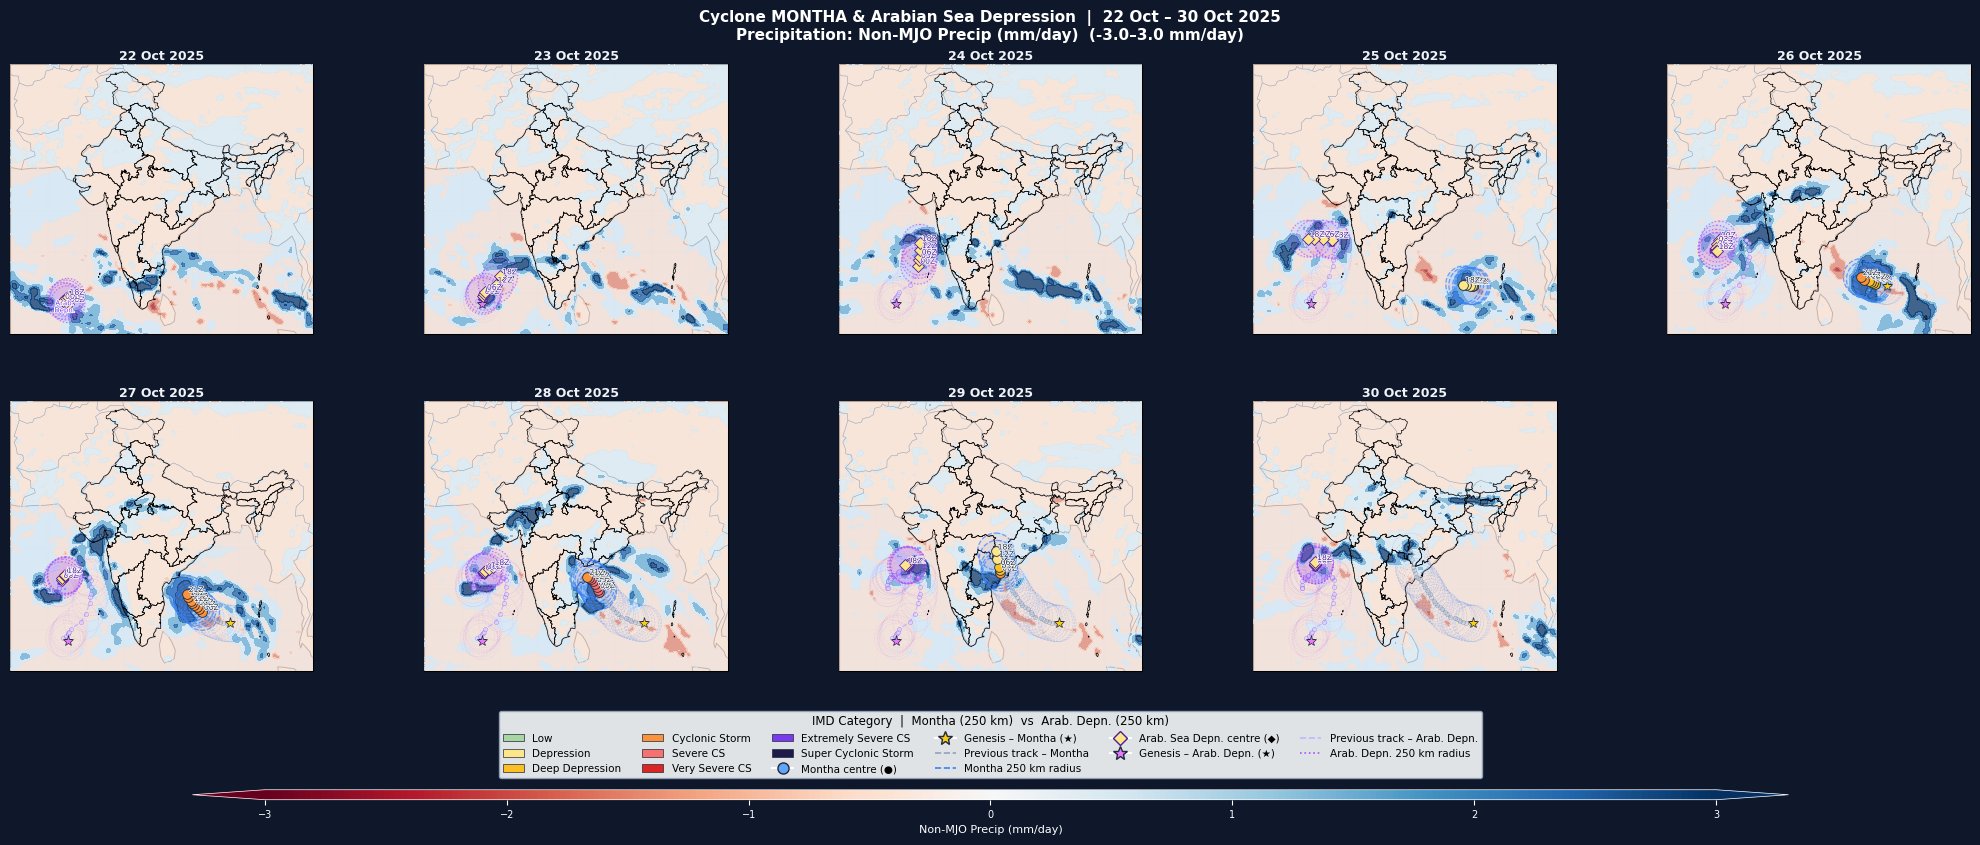

In [54]:
"""
=============================================================================
Cyclone MONTHA – Daily Track Maps  |  Precipitation Overlay + Dual Cyclone
=============================================================================
REQUIREMENTS:
    pip install matplotlib cartopy geopandas pandas openpyxl numpy netCDF4
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import netCDF4 as nc
from datetime import datetime, timedelta
from datetime import date as date_type  
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# ── USER CONFIGURATION  (edit only this section) ─────────────────────────────
# =============================================================================

EXCEL_FILE     = r"D:\PHD 2025~\LOW PRESSURE TRACKS\SCS_Montha_Oct_2025.xlsx"
EXCEL_FILE_2   = r"D:\PHD 2025~\LOW PRESSURE TRACKS\D_Arabian_Sea_Oct_2025.xlsx"
SHAPEFILE_PATH = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# ── PRECIPITATION NetCDF FILES ────────────────────────────────────────────────
PRECIP_TOTAL_FILE   = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\ERA5_merged_1980_2026_new.nc"
PRECIP_ANOMALY_FILE = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\anomaly_new.nc"
PRECIP_NONMJO_FILE  = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\non_mjo.nc"
PRECIP_MJO_FILE     = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\lanczos_mjo_only.nc"

# =============================================================================
# ── PRECIPITATION SWITCHES ────────────────────────────────────────────────────
#
#  Turn ON exactly ONE switch at a time.
#  True  = that file's data will be plotted as the background shading.
#  False = skip.
#
#  Only the FIRST True switch in this list will be used if you
#  accidentally set more than one to True — a warning will be printed.
# =============================================================================

USE_TOTAL_PRECIP   = False   # ERA5 merged  |  variable: tp     |  only ≥ 0  mm/day
USE_PRECIP_ANOMALY = False   # anomaly_new  |  variable: tp     |  can be +/−
USE_NONMJO_PRECIP  = True   # non_mjo      |  variable: tp_non_mjo  |  can be +/−
USE_MJO_PRECIP     = False   # lanczos_mjo  |  variable: tp_mjo |  can be +/−

# =============================================================================
# ── COLORBAR LIMITS & DIVISIONS ───────────────────────────────────────────────
#
#  Set the min / max of the colorbar and how many contour levels to use.
#
#  For TOTAL PRECIP (only positive):
#    PRECIP_VMIN =  0.0,  PRECIP_VMAX = 25.0,  PRECIP_LEVELS = 13
#
#  For ANOMALY / MJO / NON-MJO (positive and negative):
#    PRECIP_VMIN = -15.0, PRECIP_VMAX = 15.0,  PRECIP_LEVELS = 13
#
#  PRECIP_LEVELS = number of colour bands  (more = finer gradation)
#    e.g. 11 → steps of ~2.5 mm  |  21 → steps of ~1.25 mm
# =============================================================================

# # For total precipitation, we expect values from 0 to maybe 25 mm/day or more.
# PRECIP_VMIN   =  0.0    # lower limit  (mm/day)
# PRECIP_VMAX   = 5.0    # upper limit  (mm/day)
# PRECIP_LEVELS = 5      # number of colour bands

# PRECIP_ALPHA  = 0.72    # transparency of precipitation shading (0=invisible, 1=solid)

# For ANOMALY / MJO / NON-MJO (positive and negative):

PRECIP_VMIN   =  -3.0    # lower limit  (mm/day)
PRECIP_VMAX   = 3.0    # upper limit  (mm/day)
PRECIP_LEVELS = 7      # number of colour bands

PRECIP_ALPHA  = 0.72    # transparency of precipitation shading (0=invisible, 1=solid)

# =============================================================================
# ── COLORMAP SELECTION ────────────────────────────────────────────────────────
#
#  The code auto-selects a sensible colormap based on which switch is ON,
#  but you can override here:
#
#  For total (only positive)  → "YlGnBu"  (yellow → green → blue)
#  For anomaly / MJO / non-MJO (diverging) →
#       "RdYlGn"  red (−) → yellow (0) → green (+)   ← default
#       "BrBG"    brown (−) → white (0) → teal (+)
#       "RdBu_r"  red (−) → white (0) → blue (+)
#
#  Set to None to let the code auto-pick based on active switch.
# =============================================================================

COLORMAP_OVERRIDE = None    # e.g.  "RdYlGn"  or  None


# ── DATE RANGE ───────────────────────────────────────────────────────────────
START_DATE = "22-10-2025"
END_DATE   = "30-10-2025"

# ── LAYOUT ───────────────────────────────────────────────────────────────────
NCOLS = 5

# ── SUBPLOT SIZE ─────────────────────────────────────────────────────────────
PLOT_WIDTH_PER_COL  = 3.8
PLOT_HEIGHT_PER_ROW = 4.2


# ── MAP DOMAIN  [lon_min, lon_max, lat_min, lat_max] ─────────────────────────
MAP_EXTENT = [60, 100, 5, 38]

# ── CUMULATIVE TRACK STYLE (Montha – primary) ─────────────────────────────────
CUMUL_LINE_COLOR  = "#94a3b8"
CUMUL_LINE_WIDTH  = 1.0
CUMUL_LINE_STYLE  = "--"
CUMUL_DOT_COLOR   = "#cbd5e1"
CUMUL_DOT_SIZE    = 3
CUMUL_DOT_ALPHA   = 0.6

# ── CUMULATIVE TRACK STYLE (Arabian Sea Depression – secondary) ───────────────
CUMUL2_LINE_COLOR = "#c4b5fd"
CUMUL2_LINE_WIDTH = 1.0
CUMUL2_LINE_STYLE = "--"
CUMUL2_DOT_COLOR  = "#ddd6fe"
CUMUL2_DOT_SIZE   = 3
CUMUL2_DOT_ALPHA  = 0.6

# ── RADIUS CIRCLE CONFIGURATION ───────────────────────────────────────────────
MONTHA_RADIUS_KM         = 250
MONTHA_CIRCLE_COLOR      = "#3b82f6"
MONTHA_CIRCLE_LINEWIDTH  = 0.9
MONTHA_CIRCLE_LINESTYLE  = "--"
MONTHA_CIRCLE_ALPHA      = 0.70
MONTHA_CIRCLE_FILL_COLOR = "#3b82f6"
MONTHA_CIRCLE_FILL_ALPHA = 0.06
MONTHA_DRAW_CIRCLE       = True

ARAB_RADIUS_KM           = 250
ARAB_CIRCLE_COLOR        = "#a855f7"
ARAB_CIRCLE_LINEWIDTH    = 0.9
ARAB_CIRCLE_LINESTYLE    = ":"
ARAB_CIRCLE_ALPHA        = 0.70
ARAB_CIRCLE_FILL_COLOR   = "#a855f7"
ARAB_CIRCLE_FILL_ALPHA   = 0.06
ARAB_DRAW_CIRCLE         = True

# ── OUTPUT ───────────────────────────────────────────────────────────────────
OUTPUT_FILE          = "BOB_ArabianSea_cyclones_October2025.png"
OUTPUT_DPI           = 180
SAVE_INDIVIDUAL_DAYS = False


# =============================================================================
# ── CATEGORY COLOUR MAP (IMD scale) ──────────────────────────────────────────
# =============================================================================

CATEGORY_COLORS = {
    "L"   : "#a8d5a2",
    "D"   : "#fde68a",
    "DD"  : "#fbbf24",
    "CS"  : "#fb923c",
    "SCS" : "#f87171",
    "VSCS": "#dc2626",
    "ESCS": "#7c3aed",
    "SuCS": "#1e1b4b",
}
DEFAULT_COLOR = "#60a5fa"

CATEGORY_LABELS = {
    "L"   : "Low",
    "D"   : "Depression",
    "DD"  : "Deep Depression",
    "CS"  : "Cyclonic Storm",
    "SCS" : "Severe CS",
    "VSCS": "Very Severe CS",
    "ESCS": "Extremely Severe CS",
    "SuCS": "Super Cyclonic Storm",
}

def cat_color(cat):
    return CATEGORY_COLORS.get(str(cat).strip(), DEFAULT_COLOR)

def cat_label(cat):
    return CATEGORY_LABELS.get(str(cat).strip(), str(cat).strip())


# =============================================================================
# ── PRECIPITATION LOADER ──────────────────────────────────────────────────────
# =============================================================================

def resolve_precip_config():
    """
    Read the four switches and return:
        (filepath, varname, is_diverging, label)
    Only the first True switch wins. Returns None if all are False.
    """
    candidates = [
        (USE_TOTAL_PRECIP,   PRECIP_TOTAL_FILE,   "tp",         False, "Total Precip (mm/day)"),
        (USE_PRECIP_ANOMALY, PRECIP_ANOMALY_FILE,  "tp",         True,  "Precip Anomaly (mm/day)"),
        (USE_NONMJO_PRECIP,  PRECIP_NONMJO_FILE,   "tp_non_mjo", True,  "Non-MJO Precip (mm/day)"),
        (USE_MJO_PRECIP,     PRECIP_MJO_FILE,      "tp_mjo",     True,  "MJO Precip (mm/day)"),
    ]
    active = [(fp, vn, div, lbl) for flag, fp, vn, div, lbl in candidates if flag]
    if len(active) == 0:
        return None
    if len(active) > 1:
        print(f"  ⚠ WARNING: {len(active)} precipitation switches are ON. "
              f"Using only the first one: '{active[0][3]}'")
    return active[0]   # (filepath, varname, is_diverging, label)


def load_precip_dataset(filepath, varname):
    """
    Open a NetCDF file and return (ds, lons, lats, time_array).
    Keeps the dataset open — caller must close ds when done.
    time_array is an array of Python date objects.
    """
    ds        = nc.Dataset(filepath, "r")
    lons      = ds.variables["longitude"][:]
    lats      = ds.variables["latitude"][:]

    # time dimension name differs between files
    t_key     = "valid_time" if "valid_time" in ds.variables else "time"
    t_raw     = ds.variables[t_key][:]            # seconds since 1970-01-01
    times     = np.array([
        (datetime(1970, 1, 1) + timedelta(seconds=float(s))).date()
        for s in t_raw
    ])
    return ds, lons, lats, times, t_key


def get_precip_field(ds, varname, times, target_date):
    """
    Extract the 2-D precipitation field (lat × lon) for target_date.
    Converts m/day → mm/day.
    Returns None if the date is not found.
    """
    idx_arr = np.where(times == target_date)[0]
    if len(idx_arr) == 0:
        return None
    idx  = idx_arr[0]
    data = ds.variables[varname][idx, :, :]   # shape: (lat, lon)
    data = np.ma.filled(data, np.nan)
    data = data * 1000.0                       # m → mm
    return data


def build_colormap(is_diverging):
    """
    Return a colormap appropriate for the data type.
    Respects COLORMAP_OVERRIDE if set.
    """
    if COLORMAP_OVERRIDE is not None:
        return plt.get_cmap(COLORMAP_OVERRIDE)
    if is_diverging:
        # # Red(−) → Yellow(0) → Green(+)  – intuitive for rainfall anomalies
        # return plt.get_cmap("RdYlGn")
        # Red(−) → Blue(+)  – intuitive for rainfall anomalies
        return plt.get_cmap("RdBu")
    else:
        # # Yellow → Green → Blue  – classic positive-only rainfall
        # return plt.get_cmap("YlGnBu")
        # Yellow → Blue  – classic positive-only rainfall
        return plt.get_cmap("GnBu")


# =============================================================================
# ── GEODESIC RADIUS CIRCLE ────────────────────────────────────────────────────
# =============================================================================

def draw_radius_circle(ax, centre_lon, centre_lat, radius_km, proj,
                       color="#3b82f6", linewidth=0.9, linestyle="--",
                       alpha=0.7, fill_color="none", fill_alpha=0.07,
                       n_pts=180):
    R_EARTH  = 6371.0
    d        = radius_km / R_EARTH
    lat_r    = np.radians(centre_lat)
    bearings = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)

    ring_lats = np.degrees(
        np.arcsin(np.sin(lat_r) * np.cos(d) +
                  np.cos(lat_r) * np.sin(d) * np.cos(bearings))
    )
    ring_lons = centre_lon + np.degrees(
        np.arctan2(np.sin(bearings) * np.sin(d) * np.cos(lat_r),
                   np.cos(d) - np.sin(lat_r) * np.sin(np.radians(ring_lats)))
    )
    ring_lons = np.append(ring_lons, ring_lons[0])
    ring_lats = np.append(ring_lats, ring_lats[0])

    if fill_color != "none":
        ax.fill(ring_lons, ring_lats, color=fill_color,
                alpha=fill_alpha, transform=proj, zorder=7)
    ax.plot(ring_lons, ring_lats, linestyle=linestyle, color=color,
            linewidth=linewidth, alpha=alpha, transform=proj, zorder=8)


# =============================================================================
# ── OVERLAY MODULE REGISTRY ───────────────────────────────────────────────────
# =============================================================================

OVERLAY_MODULES = []


# =============================================================================
# ── SECOND SYSTEM OVERLAY  (Arabian Sea Depression) ──────────────────────────
# =============================================================================

def overlay_second_system(ax, day_date, proj, second_track_df=None, **kwargs):
    if second_track_df is None or second_track_df.empty:
        return

    past = second_track_df[second_track_df["date"] < day_date]
    if not past.empty:
        p_lons, p_lats = past["lon"].values, past["lat"].values
        ax.plot(p_lons, p_lats, CUMUL2_LINE_STYLE, color=CUMUL2_LINE_COLOR,
                linewidth=CUMUL2_LINE_WIDTH, transform=proj, zorder=6, alpha=0.8)
        ax.plot(p_lons, p_lats, "o", color=CUMUL2_DOT_COLOR,
                markersize=CUMUL2_DOT_SIZE, markeredgecolor="#7c3aed",
                markeredgewidth=0.3, transform=proj, zorder=6,
                alpha=CUMUL2_DOT_ALPHA)
        if ARAB_DRAW_CIRCLE:
            for plon, plat in zip(p_lons, p_lats):
                draw_radius_circle(ax, plon, plat, ARAB_RADIUS_KM, proj,
                    color=ARAB_CIRCLE_COLOR,
                    linewidth=max(0.3, ARAB_CIRCLE_LINEWIDTH * 0.5),
                    linestyle=ARAB_CIRCLE_LINESTYLE,
                    alpha=ARAB_CIRCLE_ALPHA * 0.35, fill_color="none")
        ax.plot(p_lons[0], p_lats[0], "*", color="#e879f9", markersize=8,
                markeredgecolor="#1e293b", markeredgewidth=0.5,
                transform=proj, zorder=9)

    day_data = second_track_df[second_track_df["date"] == day_date]
    if day_data.empty:
        return

    lons, lats   = day_data["lon"].values, day_data["lat"].values
    cats, hours  = day_data["category"].values, day_data["hour"].values

    if ARAB_DRAW_CIRCLE:
        for lon, lat in zip(lons, lats):
            draw_radius_circle(ax, lon, lat, ARAB_RADIUS_KM, proj,
                color=ARAB_CIRCLE_COLOR, linewidth=ARAB_CIRCLE_LINEWIDTH,
                linestyle=ARAB_CIRCLE_LINESTYLE, alpha=ARAB_CIRCLE_ALPHA,
                fill_color=ARAB_CIRCLE_FILL_COLOR,
                fill_alpha=ARAB_CIRCLE_FILL_ALPHA)

    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#6d28d9", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)
        for i in range(len(lons) - 1):
            dx = lons[i+1]-lons[i]; dy = lats[i+1]-lats[i]
            mx = (lons[i]+lons[i+1])/2; my = (lats[i]+lats[i+1])/2
            ax.annotate("", xy=(mx+dx*0.01, my+dy*0.01),
                xytext=(mx-dx*0.01, my-dy*0.01),
                xycoords=proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#6d28d9",
                                lw=1.0, mutation_scale=8), zorder=8)

    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "D", color=cat_color(cat), markersize=6,
                markeredgecolor="#4c1d95", markeredgewidth=0.6,
                transform=proj, zorder=10)
        ax.text(lon+0.25, lat+0.25, f"{int(hr):02d}Z", fontsize=5.5,
                color="#4c1d95", transform=proj, zorder=11,
                path_effects=[pe.withStroke(linewidth=1.0, foreground="white")])

    first_date = second_track_df["date"].min()
    if day_date == first_date and len(lons) > 0:
        ax.text(lons[0]-0.4, lats[0]-1.0, "Arab.\nDepn.", fontsize=5,
                color="#7c3aed", ha="center", transform=proj, zorder=12,
                path_effects=[pe.withStroke(linewidth=1.2, foreground="white")])


OVERLAY_MODULES.append(overlay_second_system)


# =============================================================================
# ── LOAD & CLEAN EXCEL ────────────────────────────────────────────────────────
# =============================================================================

def load_track(excel_path):
    df = pd.read_excel(excel_path, sheet_name="Sheet1")
    df = df[["Date", "Time (UTC)", "Lat (°N)", "Long (°E)",
             "ECP (hPa)", "ΔP (hPa)", "C.I. No.", "MSW (kt)", "Category"]].copy()
    df.columns = ["date_str","time_utc","lat","lon","ecp","delta_p","ci","msw","category"]
    df = df.dropna(subset=["lat","lon","date_str"])
    df["date"]     = pd.to_datetime(df["date_str"], format="%d.%m.%Y").dt.date
    df["time_utc"] = pd.to_numeric(df["time_utc"], errors="coerce").fillna(0).astype(int)
    df["hour"]     = df["time_utc"] // 100
    df = df.sort_values(["date","time_utc"]).reset_index(drop=True)
    return df


# =============================================================================
# ── DRAW ONE DAY'S SUBPLOT ────────────────────────────────────────────────────
# =============================================================================

def draw_day(ax, day_date, track_df, past_track_df, india_shp, proj,
             overlay_kwargs=None,
             precip_ds=None, precip_lons=None, precip_lats=None,
             precip_times=None, precip_varname=None,
             precip_cmap=None, precip_norm=None):

    ax.set_extent(MAP_EXTENT, crs=proj)

    # ── Base map ──────────────────────────────────────────────────────────────
    ax.add_feature(cfeature.OCEAN.with_scale("110m"),
                   facecolor="#dbeafe", zorder=1)
    ax.add_feature(cfeature.LAND.with_scale("110m"),
                   facecolor="#f1f5f9", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"),
                   linewidth=0.7, edgecolor="#334155", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),
                   linewidth=0.4, edgecolor="#94a3b8", zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.3,
                 color="#cbd5e1", alpha=0.5, linestyle="--", zorder=2)

    if india_shp is not None:
        india_shp.boundary.plot(ax=ax, linewidth=0.5, edgecolor="black", #edgecolor="#000000"
                                facecolor="none", zorder=6) #transform=proj 

    ax.set_title(day_date.strftime("%d %b %Y"), fontsize=9,
                 fontweight="bold", color="#f0f3f8", pad=3)

    # ── Precipitation shading ─────────────────────────────────────────────────
    if precip_ds is not None:
        field = get_precip_field(precip_ds, precip_varname,
                                 precip_times, day_date)
        if field is not None:
            # For total precip: mask negative values (artifacts)
            if not precip_norm.vmin < 0:
                field = np.where(field < 0, np.nan, field)

            cf = ax.contourf(
                precip_lons, precip_lats, field,
                levels=np.linspace(PRECIP_VMIN, PRECIP_VMAX, PRECIP_LEVELS),
                cmap=precip_cmap, norm=precip_norm,
                transform=proj, alpha=PRECIP_ALPHA,
                zorder=3, extend="both"
            )

    # ── Overlay modules ───────────────────────────────────────────────────────
    if overlay_kwargs is None:
        overlay_kwargs = {}
    for module_fn in OVERLAY_MODULES:
        module_fn(ax, day_date, proj, **overlay_kwargs)

    # ── CUMULATIVE TRACK – Montha ─────────────────────────────────────────────
    if past_track_df is not None and not past_track_df.empty:
        p_lons, p_lats = past_track_df["lon"].values, past_track_df["lat"].values
        ax.plot(p_lons, p_lats, CUMUL_LINE_STYLE, color=CUMUL_LINE_COLOR,
                linewidth=CUMUL_LINE_WIDTH, transform=proj, zorder=6, alpha=0.8)
        ax.plot(p_lons, p_lats, "o", color=CUMUL_DOT_COLOR,
                markersize=CUMUL_DOT_SIZE, markeredgecolor="#64748b",
                markeredgewidth=0.3, transform=proj, zorder=6, alpha=CUMUL_DOT_ALPHA)
        if MONTHA_DRAW_CIRCLE:
            for plon, plat in zip(p_lons, p_lats):
                draw_radius_circle(ax, plon, plat, MONTHA_RADIUS_KM, proj,
                    color=MONTHA_CIRCLE_COLOR,
                    linewidth=max(0.3, MONTHA_CIRCLE_LINEWIDTH * 0.5),
                    linestyle=MONTHA_CIRCLE_LINESTYLE,
                    alpha=MONTHA_CIRCLE_ALPHA * 0.35, fill_color="none")
        ax.plot(p_lons[0], p_lats[0], "*", color="#facc15", markersize=8,
                markeredgecolor="#1e293b", markeredgewidth=0.5,
                transform=proj, zorder=9)

    # ── TODAY'S TRACK – Montha ────────────────────────────────────────────────
    day_data = track_df[track_df["date"] == day_date]
    if day_data.empty:
        return

    lons, lats   = day_data["lon"].values, day_data["lat"].values
    cats, hours  = day_data["category"].values, day_data["hour"].values

    if MONTHA_DRAW_CIRCLE:
        for lon, lat in zip(lons, lats):
            draw_radius_circle(ax, lon, lat, MONTHA_RADIUS_KM, proj,
                color=MONTHA_CIRCLE_COLOR, linewidth=MONTHA_CIRCLE_LINEWIDTH,
                linestyle=MONTHA_CIRCLE_LINESTYLE, alpha=MONTHA_CIRCLE_ALPHA,
                fill_color=MONTHA_CIRCLE_FILL_COLOR,
                fill_alpha=MONTHA_CIRCLE_FILL_ALPHA)

    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#1e3a5f", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)
        for i in range(len(lons) - 1):
            dx = lons[i+1]-lons[i]; dy = lats[i+1]-lats[i]
            mx = (lons[i]+lons[i+1])/2; my = (lats[i]+lats[i+1])/2
            ax.annotate("", xy=(mx+dx*0.01, my+dy*0.01),
                xytext=(mx-dx*0.01, my-dy*0.01),
                xycoords=proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#1e3a5f",
                                lw=1.0, mutation_scale=8), zorder=8)

    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "o", color=cat_color(cat), markersize=7,
                markeredgecolor="#1e293b", markeredgewidth=0.6,
                transform=proj, zorder=10)
        ax.text(lon+0.25, lat+0.25, f"{int(hr):02d}Z", fontsize=5.5,
                color="#1e293b", transform=proj, zorder=11,
                path_effects=[pe.withStroke(linewidth=1.0, foreground="white")])


# =============================================================================
# ── MAIN ─────────────────────────────────────────────────────────────────────
# =============================================================================

def main():

    proj = ccrs.PlateCarree()

    # ── Date range ────────────────────────────────────────────────────────────
    start     = datetime.strptime(START_DATE, "%d-%m-%Y").date()
    end       = datetime.strptime(END_DATE,   "%d-%m-%Y").date()
    date_list = [start + timedelta(days=i)
                 for i in range((end - start).days + 1)]
    n_days = len(date_list)
    print(f"Date range : {start} → {end}  ({n_days} days)")

    # ── Resolve which precipitation file to use ───────────────────────────────
    precip_cfg = resolve_precip_config()
    precip_ds = precip_lons = precip_lats = precip_times = None
    precip_varname = precip_cmap = precip_norm = None
    precip_label = ""

    if precip_cfg is not None:
        fp, varname, is_diverging, precip_label = precip_cfg
        print(f"Precipitation  : {precip_label}  ←  {fp}")
        precip_ds, precip_lons, precip_lats, precip_times, _ = \
            load_precip_dataset(fp, varname)
        precip_varname = varname
        precip_cmap    = build_colormap(is_diverging)
        precip_norm    = mcolors.Normalize(vmin=PRECIP_VMIN, vmax=PRECIP_VMAX)
        print(f"  Colorbar     : {PRECIP_VMIN} → {PRECIP_VMAX} mm/day  "
              f"|  {PRECIP_LEVELS} levels  |  cmap = {precip_cmap.name}")
    else:
        print("Precipitation  : OFF (all switches are False)")

    # ── Track data ────────────────────────────────────────────────────────────
    print("Loading Cyclone Montha track...")
    track_df = load_track(EXCEL_FILE)
    print(f"  → {len(track_df)} points  |  "
          f"{track_df['date'].min()} – {track_df['date'].max()}")

    print("Loading Arabian Sea Depression track...")
    try:
        track_df2 = load_track(EXCEL_FILE_2)
        print(f"  → {len(track_df2)} points  |  "
              f"{track_df2['date'].min()} – {track_df2['date'].max()}")
    except Exception as e:
        print(f"  ⚠ Second system skipped: {e}")
        track_df2 = None

    # ── Shapefile ─────────────────────────────────────────────────────────────
    print("Loading India shapefile...")
    try:
        # india_shp = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
        india_shp = gpd.read_file(SHAPEFILE_PATH)

        # Set CRS manually (most India shapefiles are already in WGS84)
        india_shp = india_shp.set_crs(epsg=4326, allow_override=True)
        print(f"  → {len(india_shp)} features")
    except Exception as e:
        print(f"  ⚠ Shapefile skipped: {e}")
        india_shp = None

    # # ── Figure grid ───────────────────────────────────────────────────────────
    # ncols = NCOLS
    # nrows = int(np.ceil(n_days / ncols))
    # fig_w = ncols * PLOT_WIDTH_PER_COL
    # # fig_h = nrows * PLOT_HEIGHT_PER_ROW

    # lon_range = MAP_EXTENT[1] - MAP_EXTENT[0]
    # lat_range = MAP_EXTENT[3] - MAP_EXTENT[2]

    # aspect_ratio = lat_range / lon_range

    # fig_h = nrows * PLOT_HEIGHT_PER_ROW * aspect_ratio

    # print(f"Grid       : {nrows} rows × {ncols} cols  |  "
    #       f"Figure: {fig_w:.1f} × {fig_h:.1f} in")

    # fig = plt.figure(figsize=(fig_w, fig_h), facecolor="#0f172a")

    # # Build title — include which precipitation layer is active
    # precip_title = precip_label if precip_label else "No precipitation overlay"
    # fig.suptitle(
    #     f"Cyclone MONTHA & Arabian Sea Depression  |  "
    #     f"{start.strftime('%d %b')} – {end.strftime('%d %b %Y')}\n"
    #     f"Precipitation: {precip_title}  "
    #     f"({PRECIP_VMIN}–{PRECIP_VMAX} mm/day)",
    #     fontsize=11, fontweight="bold", color="white",
    #     y=0.999, va="top"
    # )

    # overlay_kwargs = {"second_track_df": track_df2}




    # ── Figure grid ───────────────────────────────────────────────────────────
    ncols = NCOLS
    nrows = int(np.ceil(n_days / ncols))

    # ── Dynamic width scaling (prevents columns from spreading too much)
    # fig_w = ncols * PLOT_WIDTH_PER_COL * (1 + 0.05 * max(0, nrows - 2))
    # ── Map aspect ratio FIRST ───────────────────────────────────────────────
    lon_range = MAP_EXTENT[1] - MAP_EXTENT[0]
    lat_range = MAP_EXTENT[3] - MAP_EXTENT[2]
    aspect_ratio = lat_range / lon_range
    scale_factor = 1.2   # 🔥 global zoom (eg.Huge @ss subplots 0.5===> smaller subplots 1.9)

    fig_w = ncols * PLOT_WIDTH_PER_COL * scale_factor
    fig_h = nrows * PLOT_HEIGHT_PER_ROW * aspect_ratio * scale_factor    

    # # ── Dynamic height scaling (based on map aspect ratio)
    # lon_range = MAP_EXTENT[1] - MAP_EXTENT[0]
    # lat_range = MAP_EXTENT[3] - MAP_EXTENT[2]
    # aspect_ratio = lat_range / lon_range

    # fig_h = nrows * PLOT_HEIGHT_PER_ROW * aspect_ratio

    print(f"Grid       : {nrows} rows × {ncols} cols  |  "
            f"Figure: {fig_w:.1f} × {fig_h:.1f} in")

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="#0f172a")

    # ── Dynamic spacing control (VERY IMPORTANT)
    wspace = max(0.01, 0.12 - 0.025 * max(0, nrows - 2))

    plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.93,
    bottom=0.15,
    hspace=0.25,
    wspace=wspace
    )

    # ── Title
    precip_title = precip_label if precip_label else "No precipitation overlay"
    fig.suptitle(
        f"Cyclone MONTHA & Arabian Sea Depression  |  "
        f"{start.strftime('%d %b')} – {end.strftime('%d %b %Y')}\n"
        f"Precipitation: {precip_title}  "
        f"({PRECIP_VMIN}–{PRECIP_VMAX} mm/day)",
        fontsize=11, fontweight="bold", color="white",
        y=0.995, va="top"
    )

    overlay_kwargs = {"second_track_df": track_df2}


    # ── Draw subplots ─────────────────────────────────────────────────────────
    for idx, day_date in enumerate(date_list):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)

        past_mask  = track_df["date"] < day_date
        past_track = track_df[past_mask].copy() if past_mask.any() else None

        draw_day(
            ax, day_date, track_df, past_track, india_shp, proj,
            overlay_kwargs   = overlay_kwargs,
            precip_ds        = precip_ds,
            precip_lons      = precip_lons,
            precip_lats      = precip_lats,
            precip_times     = precip_times,
            precip_varname   = precip_varname,
            precip_cmap      = precip_cmap,
            precip_norm      = precip_norm,
        )

        if SAVE_INDIVIDUAL_DAYS:
            sf = plt.figure(figsize=(PLOT_WIDTH_PER_COL*1.5,
                                     PLOT_HEIGHT_PER_ROW*1.5))
            sa = sf.add_subplot(1, 1, 1, projection=proj)
            draw_day(sa, day_date, track_df, past_track, india_shp, proj,
                     overlay_kwargs=overlay_kwargs,
                     precip_ds=precip_ds, precip_lons=precip_lons,
                     precip_lats=precip_lats, precip_times=precip_times,
                     precip_varname=precip_varname,
                     precip_cmap=precip_cmap, precip_norm=precip_norm)
            sf.savefig(f"day_{day_date}.png", dpi=OUTPUT_DPI,
                       bbox_inches="tight")
            plt.close(sf)

    # Hide unused panels
    for idx in range(n_days, nrows * ncols):
        fig.add_subplot(nrows, ncols, idx + 1).set_visible(False)

    # ── Shared precipitation colorbar ────────────────────────────────────────
    if precip_ds is not None:
        sm = plt.cm.ScalarMappable(cmap=precip_cmap, norm=precip_norm)
        sm.set_array([])
        cbar_ax = fig.add_axes([0.15, 0.045, 0.70, 0.012])  # [left,bottom,w,h]
        cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                          extend="both")
        cb.set_label(precip_label, color="white", fontsize=8)
        cb.ax.xaxis.set_tick_params(color="white", labelsize=7)
        plt.setp(cb.ax.xaxis.get_ticklabels(), color="white")
        cb.outline.set_edgecolor("white")
        cb.outline.set_linewidth(0.5)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=color, edgecolor="#1e293b",
                       linewidth=0.5, label=cat_label(cat))
        for cat, color in CATEGORY_COLORS.items()
    ]
    legend_handles += [
        plt.Line2D([0],[0], marker="o", color="w",
                   markerfacecolor="#60a5fa", markeredgecolor="#1e293b",
                   markersize=8, label="Montha centre (●)"),
        plt.Line2D([0],[0], marker="*", color="w",
                   markerfacecolor="#facc15", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Montha (★)"),
        plt.Line2D([0],[0], linestyle=CUMUL_LINE_STYLE,
                   color=CUMUL_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Montha"),
        plt.Line2D([0],[0], linestyle=MONTHA_CIRCLE_LINESTYLE,
                   color=MONTHA_CIRCLE_COLOR, linewidth=1.2,
                   label=f"Montha {MONTHA_RADIUS_KM} km radius"),
        plt.Line2D([0],[0], marker="D", color="w",
                   markerfacecolor="#fde68a", markeredgecolor="#4c1d95",
                   markersize=7, label="Arab. Sea Depn. centre (◆)"),
        plt.Line2D([0],[0], marker="*", color="w",
                   markerfacecolor="#e879f9", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Arab. Depn. (★)"),
        plt.Line2D([0],[0], linestyle=CUMUL2_LINE_STYLE,
                   color=CUMUL2_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Arab. Depn."),
        plt.Line2D([0],[0], linestyle=ARAB_CIRCLE_LINESTYLE,
                   color=ARAB_CIRCLE_COLOR, linewidth=1.2,
                   label=f"Arab. Depn. {ARAB_RADIUS_KM} km radius"),
    ]

    # legend sits above the colorbar
    legend_bottom = 0.065 if precip_ds is not None else 0.01
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=min(len(legend_handles), 6),
               fontsize=7.5, frameon=True, framealpha=0.9,
               facecolor="#f8fafc", edgecolor="#94a3b8",
               title=f"IMD Category  |  Montha ({MONTHA_RADIUS_KM} km)  "
                     f"vs  Arab. Depn. ({ARAB_RADIUS_KM} km)",
               title_fontsize=8.5,
               bbox_to_anchor=(0.5, legend_bottom))

    rect_bottom = 0.11 if precip_ds is not None else 0.06
    # plt.tight_layout(rect=[0, rect_bottom, 1, 0.994])

    plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.93,
    bottom=0.20,
    hspace=0.25,   # 🔥 row spacing
    wspace=0.05    # 🔥 column spacing
    )

    plt.savefig(OUTPUT_FILE, dpi=OUTPUT_DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"\n✅  Saved → {OUTPUT_FILE}")

    if precip_ds is not None:
        precip_ds.close()

    plt.show()


if __name__ == "__main__":
    main()

# Lets talk about winds =

## Lets inspect the wind file structure

In [55]:
import xarray as xr

# ---- FILE PATH ----
file_path = r"D:\PHD 2025~\PHD DOWNLOADS\MOISTURE_(NO PRECIPITATION)\Moisture_1980-2026_NO_tp\ERA5_MoistureTransport_1988.nc"   # <-- change this

# ---- OPEN DATASET ----
ds = xr.open_dataset(file_path)

# ---- PRINT BASIC INFO ----
print("\n===== DATASET SUMMARY =====")
print(ds)

# ---- DIMENSIONS ----
print("\n===== DIMENSIONS =====")
for dim, size in ds.dims.items():
    print(f"{dim}: {size}")

# ---- COORDINATES ----
print("\n===== COORDINATES =====")
for coord in ds.coords:
    print(coord, ds[coord].values[:5])  # first 5 values

# ---- VARIABLES ----
print("\n===== VARIABLES =====")
for var in ds.data_vars:
    print(f"\nVariable: {var}")
    print(ds[var])

# ---- VARIABLE ATTRIBUTES ----
print("\n===== VARIABLE ATTRIBUTES =====")
for var in ds.data_vars:
    print(f"\n{var} attributes:")
    for attr, val in ds[var].attrs.items():
        print(f"  {attr}: {val}")

# ---- GLOBAL ATTRIBUTES ----
print("\n===== GLOBAL ATTRIBUTES =====")
for attr, val in ds.attrs.items():
    print(f"{attr}: {val}")


===== DATASET SUMMARY =====
<xarray.Dataset> Size: 472MB
Dimensions:         (valid_time: 366, latitude: 201, longitude: 321,
                     pressure_level: 1)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 3kB 1988-01-01 ... 1988-12-31
    expver          (valid_time) <U4 6kB ...
  * latitude        (latitude) float64 2kB 50.0 49.75 49.5 ... 0.5 0.25 0.0
  * longitude       (longitude) float64 3kB 40.0 40.25 40.5 ... 119.8 120.0
  * pressure_level  (pressure_level) float64 8B 850.0
    number          int64 8B ...
Data variables:
    msl             (valid_time, latitude, longitude) float32 94MB ...
    tcwv            (valid_time, latitude, longitude) float32 94MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 94MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 94MB ...
    q               (valid_time, pressure_level, latitude, longitude) float32 94MB ...
Attributes:
    GRIB_centre:           

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed